In [62]:
# モジュール
import numpy as np
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.setrecursionlimit(100000000)

In [63]:
# スペック部分
class spec:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e
        self.min = 0 # 最小弾数
        self.max = 0 # 最大弾数

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit:
                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            if self.balls < self.min:
                self.min = self.balls
            self.all += 1

            if x <= 1/349.9 * 0.45:
                self.kaitensuu = 0
                self.balls += 1400
                self.normal()
            elif x <= 1/349.9:
                self.kaitensuu = 0
                self.balls += 2800
                # 3/4で+0, 1/4で+1400, 1/16で+2800, 1/64で+4200, 1/256で+5600
                while random.random()<0.25:
                    self.balls +=1400
                self.rush()
    def rush(self):
        x = random.random()
        if x <= 0.76747669:
            furiwake = random.random()
            if furiwake <= 0.2:
                self.balls += 280
                if self.balls > self.max:
                    self.max = self.balls
                self.rush()
            elif furiwake <= 0.75:
                self.balls += 1400
                if self.balls > self.max:
                    self.max = self.balls
                self.rush()
            else:
                self.balls += 2800
                while random.random()<0.25:
                    self.balls +=1400

                self.rush()
        else:
            self.normal()


In [64]:
results = []
for i in tqdm(range(1000)):
    instance = spec(0, 0, 250, 20, 1000000)
    a = instance.normal()
    results.append(1000000*1000/a/4)
print(np.mean(results))

  5%|▌         | 50/1000 [00:04<01:33, 10.15it/s]


KeyboardInterrupt: 

In [ ]:
# play = 100000
# instance = spec(0, 0, 0, 16, play) # 初期化
# balls = instance.normal()
# print(250/balls*play)


15.864554777134733


In [68]:
result = []
for i in tqdm(range(10000)):
    instance = spec(0, 0, 0, 21, 2000) # 初期化
    balls = instance.normal()
    result.append(balls)


100%|██████████| 10000/10000 [00:01<00:00, 5142.67it/s]


平均収支:  7008.27942857137
標準偏差:  19518.990272929415
最大値:  137738.5714285698
最小値:  -23821.428571428998
5%点:  -18221.4285714283
95%点:  43938.57142857096
勝率:  0.5811


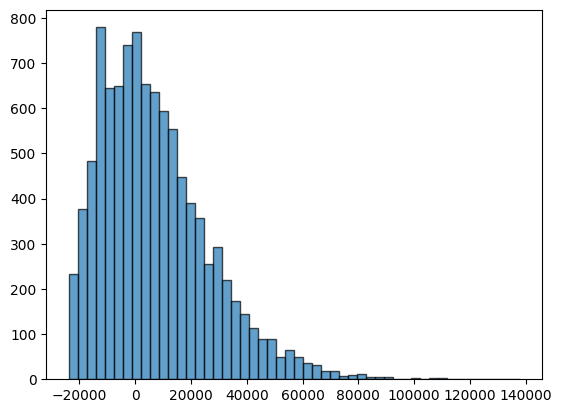

In [69]:
print("平均収支: ", np.mean(result))
print("標準偏差: ", np.std(result))
print("最大値: ", np.max(result))
print("最小値: ", np.min(result))
print("5%点: ", np.percentile(result, 5))
print("95%点: ", np.percentile(result, 95))
print("勝率: ", np.sum(np.array(result)>0)/len(result))
plt.hist(np.array(result), bins=50, edgecolor='black', alpha=0.7)
plt.show()